In [3]:
import sklearn
import xgboost
import joblib

print(sklearn.__version__)
print(xgboost.__version__)
print(joblib.__version__)

1.6.1
3.3.0
1.5.3


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# XGBoost
from xgboost import XGBClassifier

# Label encoding
from sklearn.preprocessing import LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/loan_approval_dataset.csv")

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
df = df.drop("loan_id", axis=1)

In [ ]:
df.dtypes

,0
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64
luxury_assets_value,int64


In [ ]:
df.shape

(4269, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1    education                 4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [ ]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print(df.dtypes)

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object


In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [ ]:
print("Education:")
print(df["education"].value_counts())

print("\nSelf Employed:")
print(df["self_employed"].value_counts())

print("\nLoan Status:")
print(df["loan_status"].value_counts())

Education:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Self Employed:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Loan Status:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [ ]:
print("Dependents:", df['no_of_dependents'].unique())
print("Long Term:", df['loan_term'].unique())
print("CIBIL Score Range:", df['cibil_score'].min(), "-", df['cibil_score'].max())

Dependents: [2 0 3 5 4 1]
Long Term: [12  8 20 10  4  2 18 16 14  6]
CIBIL Score Range: 300 - 900


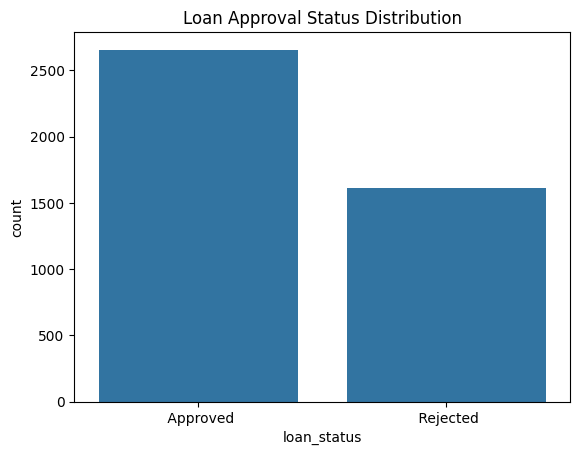

In [ ]:
sns.countplot(data=df, x="loan_status")
plt.title("Loan Approval Status Distribution")
plt.show()

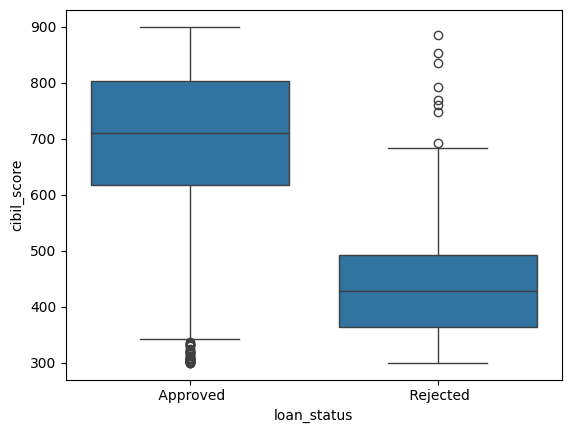

In [ ]:
sns.boxplot(data=df, x=df['loan_status'], y=df['cibil_score'])
plt.show()

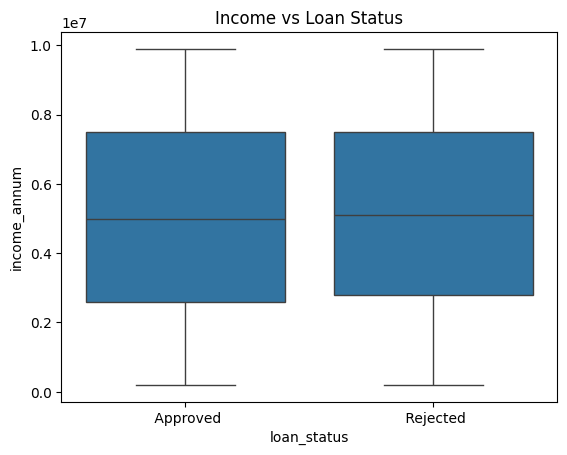

In [ ]:
sns.boxplot(data=df, x="loan_status", y="income_annum")
plt.title("Income vs Loan Status")
plt.show()

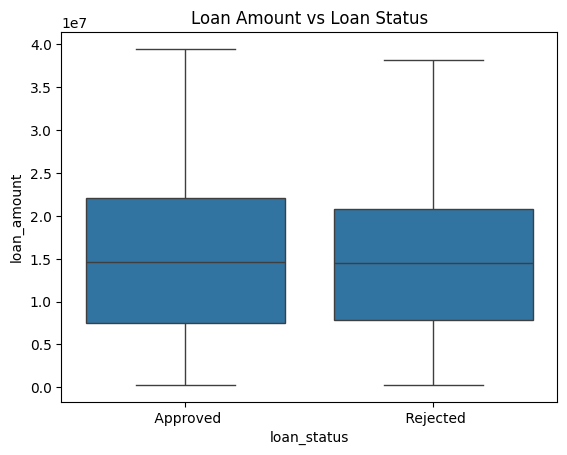

In [ ]:
sns.boxplot(data=df, x="loan_status", y="loan_amount")
plt.title("Loan Amount vs Loan Status")
plt.show()

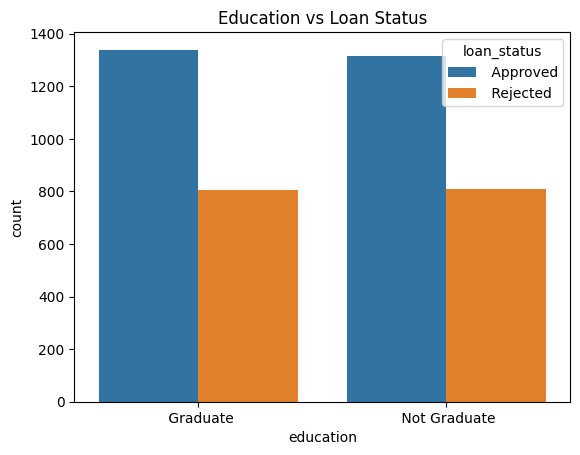

In [ ]:
sns.countplot(data=df, x="education", hue="loan_status")
plt.title("Education vs Loan Status")
plt.show()

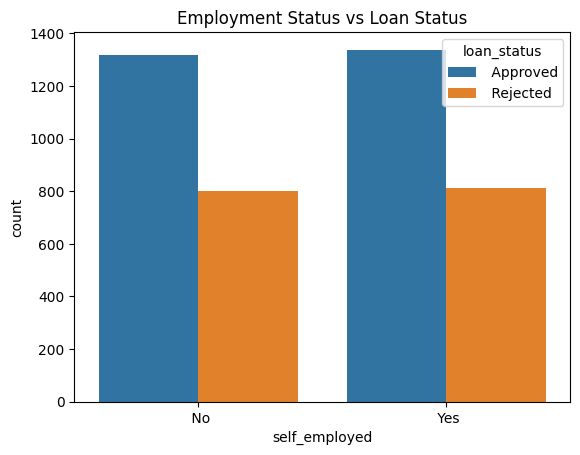

In [ ]:
sns.countplot(data=df, x="self_employed", hue="loan_status")
plt.title("Employment Status vs Loan Status")
plt.show()

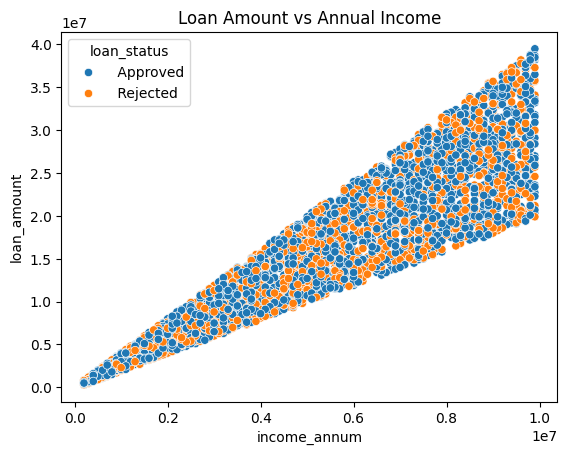

In [ ]:
sns.scatterplot(
    data=df,
    x="income_annum",
    y="loan_amount",
    hue="loan_status"
)

plt.title("Loan Amount vs Annual Income")
plt.show()

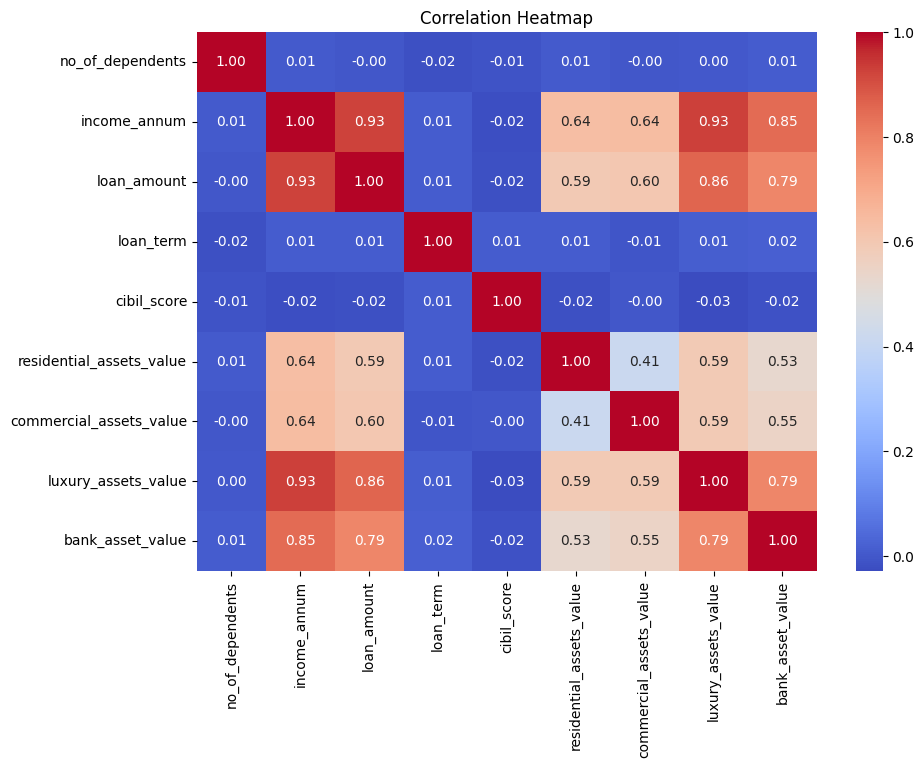

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']




In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4269, 11)
y shape: (4269,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)

Training Shape: (3415, 11)
Testing Shape: (854, 11)


In [ ]:
y = y.map({
    "Approved": 1,
    "Rejected": 0
})

In [ ]:
numeric_features = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

categorical_features = [
    "education",
    "self_employed"
]

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [ ]:
lg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [ ]:
lg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
lr_pred = lg_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", accuracy)

Accuracy: 0.905152224824356


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    Approved       0.92      0.93      0.92       536
    Rejected       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



In [ ]:
rf_model =  Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.977751756440281


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

    Approved       0.98      0.99      0.98       536
    Rejected       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [ ]:
print("Logistic Regression:", accuracy)
print("Random Forest:", rf_accuracy)

Logistic Regression: 0.905152224824356
Random Forest: 0.977751756440281


In [ ]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42
        ))
    ]
)

In [ ]:
X_xgb = df.drop("loan_status", axis=1)

y_xgb = df["loan_status"].str.strip()

In [ ]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)

In [ ]:
encoder = LabelEncoder()

y_train_xgb = encoder.fit_transform(y_train_xgb)
y_test_xgb = encoder.transform(y_test_xgb)

print(encoder.classes_)

['Approved' 'Rejected']


In [ ]:
xgb_model.fit(X_train_xgb, y_train_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 ha...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
xgb_pred = xgb_model.predict(X_test_xgb)

xgb_accuracy = accuracy_score(
    y_test_xgb,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9812646370023419


In [ ]:
print(classification_report(y_test_xgb, xgb_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [ ]:
print("Model Comparison")
print("---------------------------")

print("Logistic Regression :", round(accuracy, 4))
print("Random Forest       :", round(rf_accuracy, 4))
print("XGBoost             :", round(xgb_accuracy, 4))

Model Comparison
---------------------------
Logistic Regression : 0.9052
Random Forest       : 0.9778
XGBoost             : 0.9813


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

print(comparison)

                 Model  Accuracy  Accuracy (%)
0  Logistic Regression  0.905152     90.515222
1        Random Forest  0.977752     97.775176
2              XGBoost  0.981265     98.126464


In [ ]:
cm = confusion_matrix(y_test_xgb, xgb_pred)

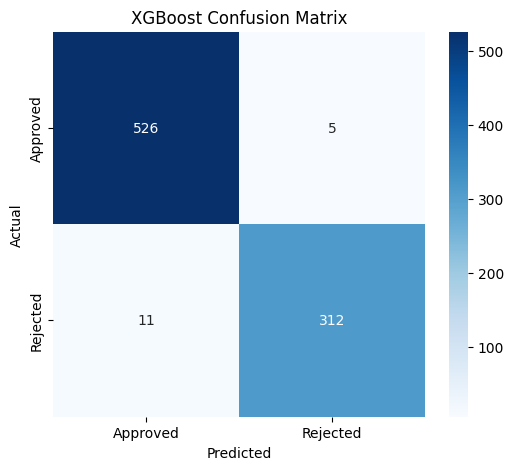

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import joblib

joblib.dump(xgb_model, "loan_approval_xgboost.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [ ]:
import sklearn
import xgboost
import joblib

print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
xgboost: 3.4.1
joblib: 1.6.0
